# Distorted Visual Sequence Pattern Recognition — CRNN Solution

**Architecture:** CNN → BiLSTM → CTC Loss  
**Dataset:** 20,000 grayscale CAPTCHA-style images, 6-character alphanumeric labels  
**Metric:** Character Error Rate (CER) — lower is better


In [1]:
import os
import re
import cv2
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset

# ── Paths (update if your layout differs) ─────────────────────────────
TRAIN_CSV     = '/kaggle/input/datasets/aklduiawrh/cig-dataset/cig_ps/train-labels.csv'
TRAIN_IMG_DIR = '/kaggle/input/datasets/aklduiawrh/cig-dataset/cig_ps/train_images'
TEST_IMG_DIR  = '/kaggle/input/datasets/aklduiawrh/cig-dataset/cig_ps/test_images'

df = pd.read_csv(TRAIN_CSV)
df.head()


,Unnamed: 0,image,text
0,0,train-0.png,BU522X
1,1,train-1.png,XQ8NE2
2,2,train-2.png,DTZD3E
3,3,train-3.png,SM424H
4,4,train-4.png,6YVTQR


### Checking for text labels with length not equal to 6

In [2]:
df[df['text'].astype(str).str.len() > 6]


,Unnamed: 0,image,text
2184,2184,train-2184.png,5.40E+12
6819,6819,train-6819.png,04-Mar-54


### Correcting incorrect labels

In [3]:
# Row 2184: '5.40E+12'  (scientific notation artifact) → corrected 6-char token
# Row 6819: '04-Mar-54' (date format artifact)          → corrected 6-char token
df.loc[2184, 'text'] = '5396E9'
df.loc[6819, 'text'] = '4MAR54'

# Verify fix
df[df['text'].astype(str).str.len() > 6]


,Unnamed: 0,image,text


In [4]:
df[df['text'].astype(str).str.len() < 6]


,Unnamed: 0,image,text


In [5]:
df.shape


(20000, 3)

### Character Vocabulary & Label Encoding

- Define the set of valid characters (`A-Z`, `0-9`).
- Create mappings between characters and integer indices.
- Reserve one extra index as the CTC blank token.
- Convert text labels into integer sequences for model training.


In [6]:
CHARS = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

char_to_idx = {ch: idx for idx, ch in enumerate(CHARS)}
idx_to_char = {idx: ch for ch, idx in char_to_idx.items()}

NUM_CLASSES = len(CHARS) + 1   # 36 characters + 1 CTC blank
BLANK_IDX   = len(CHARS)       # blank index = 36

print(f'Total characters : {len(CHARS)}')
print(f'BLANK_IDX        : {BLANK_IDX}')
print(f'NUM_CLASSES      : {NUM_CLASSES}')


def encode_label(label: str):
    """
    Converts a text label into integer indices.
    Example:
        'AXU323' -> [0, 23, 20, 29, 28, 29]
    """
    label = str(label).strip().upper()

    encoded = []
    for ch in label:
        if ch not in char_to_idx:
            raise ValueError(f"Unknown character '{ch}' found in label: {label}")
        encoded.append(char_to_idx[ch])

    return encoded


# Sanity check
print(encode_label('AXU323'))
print(''.join(idx_to_char[i] for i in encode_label('AXU323')))


Total characters : 36
BLANK_IDX        : 36
NUM_CLASSES      : 37
[0, 23, 20, 29, 28, 29]
AXU323


In [7]:
def preprocess_image(
    image_path,
    img_height=100,
    img_width=200,
    use_clahe=True,
    transform=None
):
    """
    Loads image, applies preprocessing, optional augmentation,
    and converts it to a PyTorch tensor.

    Output:
        tensor of shape (1, H, W)
    """

    # 1. Load grayscale image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise FileNotFoundError(f'Image not found at path: {image_path}')

    # 2. Resize image
    image = cv2.resize(image, (img_width, img_height))

    # 3. CLAHE preprocessing — adaptive contrast enhancement
    if use_clahe:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        image = clahe.apply(image)

    # 4. Apply augmentation only if transform is given
    if transform is not None:
        augmented = transform(image=image)
        image     = augmented['image']

    # 5. Normalize to [0, 1]
    image = image.astype(np.float32) / 255.0

    # 6. Normalize to [-1, 1]
    image = (image - 0.5) / 0.5

    # 7. H, W  ->  1, H, W
    image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)

    return image


### Data Augmentation

- Apply random geometric transformations (shift, scale, rotation) to improve robustness to misalignment and distortions.
- Add Gaussian noise and motion blur to simulate real-world image degradation.
- Randomly adjust brightness and contrast to handle varying visual conditions.
- Use coarse dropout (random occlusion) to make the model resilient to missing or partially hidden characters.
- Augmentations are applied only during training to improve generalisation and reduce overfitting.


In [8]:
import albumentations as A

train_transform = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.08,
        rotate_limit=8,
        border_mode=cv2.BORDER_CONSTANT,
        fill=255,
        p=0.35
    ),

    A.GaussNoise(
        std_range=(0.02, 0.08),
        p=0.35
    ),

    A.MotionBlur(
        blur_limit=3,
        p=0.15
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.30
    ),

    A.CoarseDropout(
        num_holes_range=(1, 1),
        hole_height_range=(5, 15),
        hole_width_range=(5, 15),
        fill=255,
        p=0.25
    ),
])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
# Quick shape + range check on one training image
sample_path = os.path.join(TRAIN_IMG_DIR, df.loc[0, 'image'])

x = preprocess_image(sample_path, transform=train_transform)

print('Shape :', x.shape)
print('Min   :', x.min().item())
print('Max   :', x.max().item())


Shape : torch.Size([1, 100, 200])
Min   : -1.0
Max   : 1.0


#### Original vs Augmented image

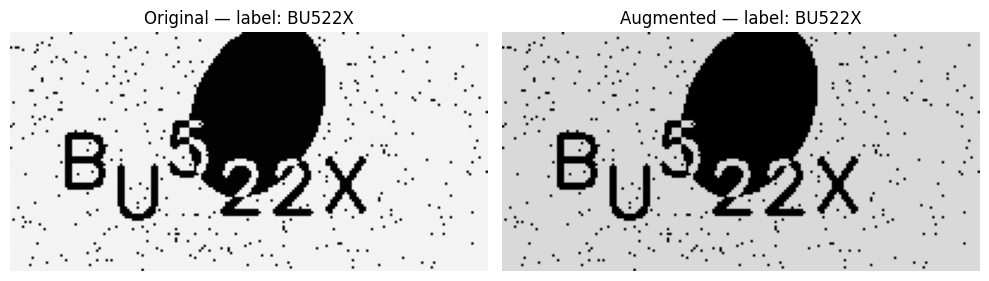

In [10]:
import matplotlib.pyplot as plt

sample_path = os.path.join(TRAIN_IMG_DIR, df.loc[0, 'image'])
label_0     = df.loc[0, 'text']

original  = preprocess_image(sample_path, transform=None)
augmented = preprocess_image(sample_path, transform=train_transform)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(original.squeeze(0),  cmap='gray', vmin=-1, vmax=1)
axes[0].set_title(f'Original — label: {label_0}')
axes[0].axis('off')

axes[1].imshow(augmented.squeeze(0), cmap='gray', vmin=-1, vmax=1)
axes[1].set_title(f'Augmented — label: {label_0}')
axes[1].axis('off')

plt.tight_layout()
plt.show()


### OCR Dataset Class

- Create a custom PyTorch dataset for loading CAPTCHA images and labels.
- Load and preprocess images on-the-fly, including optional augmentations during training.
- Convert text labels into integer sequences using the predefined character vocabulary.
- Return the image tensor, encoded label, label length, and original text label for CTC-based training.


In [11]:
class OCRDataset(Dataset):
    def __init__(
        self,
        df,
        image_dir,
        transform=None,
        img_height=100,
        img_width=200,
        use_clahe=True
    ):
        """
        df         : DataFrame with columns ['image', 'text']
        image_dir  : folder where train images are stored
        transform  : augmentation pipeline, only for train
        """

        self.df         = df.reset_index(drop=True)
        self.image_dir  = image_dir
        self.transform  = transform
        self.img_height = img_height
        self.img_width  = img_width
        self.use_clahe  = use_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Get image name and label from dataframe
        image_name = self.df.loc[idx, 'image']
        label_text = self.df.loc[idx, 'text']

        # 2. Create full image path
        image_path = os.path.join(self.image_dir, image_name)

        # 3. Load + preprocess + optionally augment
        image = preprocess_image(
            image_path=image_path,
            img_height=self.img_height,
            img_width=self.img_width,
            use_clahe=self.use_clahe,
            transform=self.transform
        )

        # 4. Encode label string into integer list
        encoded_label = encode_label(label_text)

        # 5. Convert label to tensor
        label_tensor = torch.tensor(encoded_label, dtype=torch.long)

        # 6. Label length required by CTC loss
        label_length = torch.tensor(len(encoded_label), dtype=torch.long)

        return {
            'image'       : image,
            'label'       : label_tensor,
            'label_length': label_length,
            'label_text'  : label_text
        }


In [12]:
def ocr_collate_fn(batch):
    """
    Custom collate function for CTC training.

    Input:
        batch = list of samples from OCRDataset

    Output:
        images        : stacked image tensors, shape (B, 1, H, W)
        labels        : all labels joined into one 1-D tensor
        label_lengths : length of each label
        label_texts   : original text labels
    """

    images = torch.stack([item['image'] for item in batch], dim=0)

    labels = torch.cat([item['label'] for item in batch], dim=0)

    label_lengths = torch.tensor(
        [item['label_length'].item() for item in batch],
        dtype=torch.long
    )

    label_texts = [item['label_text'] for item in batch]

    return {
        'images'       : images,
        'labels'       : labels,
        'label_lengths': label_lengths,
        'label_texts'  : label_texts
    }


In [13]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print('Train size:', len(train_df))
print('Valid size:', len(valid_df))


Train size: 18000
Valid size: 2000


In [14]:
train_dataset = OCRDataset(
    df=train_df,
    image_dir=TRAIN_IMG_DIR,
    transform=train_transform,
    img_height=100,
    img_width=200,
    use_clahe=True
)

valid_dataset = OCRDataset(
    df=valid_df,
    image_dir=TRAIN_IMG_DIR,
    transform=None,
    img_height=100,
    img_width=200,
    use_clahe=True
)


In [15]:
sample = train_dataset[0]

print('image shape  :', sample['image'].shape)
print('label        :', sample['label'])
print('label_length :', sample['label_length'])
print('label_text   :', sample['label_text'])


image shape  : torch.Size([1, 100, 200])
label        : tensor([23,  1, 17, 29, 12, 29])
label_length : tensor(6)
label_text   : XBR3M3


### Data Loaders

- Create training and validation data loaders for efficient batch processing.
- Shuffle training data each epoch to improve generalisation.
- Use a custom collate function to combine variable-length label sequences for CTC training.
- Enable multi-process loading and pinned memory for faster GPU training.


In [16]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    collate_fn=ocr_collate_fn,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    collate_fn=ocr_collate_fn,
    pin_memory=True
)


In [17]:
batch = next(iter(train_loader))

print('Images shape      :', batch['images'].shape)
print('Labels shape      :', batch['labels'].shape)
print('Label lengths     :', batch['label_lengths'].shape)
print('First 5 texts     :', batch['label_texts'][:5])
print('First 5 lengths   :', batch['label_lengths'][:5])


Images shape      : torch.Size([32, 1, 100, 200])
Labels shape      : torch.Size([192])
Label lengths     : torch.Size([32])
First 5 texts     : ['ZHH6FZ', 'P2T5ST', '4B8BMW', 'P2D8MC', '46NW4N']
First 5 lengths   : tensor([6, 6, 6, 6, 6])


In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F


### CRNN Architecture

- Use a CNN backbone to extract robust visual features from distorted CAPTCHA images.
- Gradually reduce the image height to 1 while preserving width as the sequence dimension.
- Convert CNN feature maps into a sequence of feature vectors.
- Process the sequence using a 2-layer Bidirectional LSTM to capture contextual dependencies between characters.
- Apply a linear classification layer to predict character probabilities at each time step.
- Train the network end-to-end using CTC Loss, eliminating the need for explicit character segmentation.


In [19]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


In [20]:
class CRNN(nn.Module):
    def __init__(
        self,
        num_classes,
        lstm_hidden=256,
        lstm_layers=2,
        dropout=0.3
    ):
        super().__init__()

        # CNN backbone
        self.cnn = nn.Sequential(
            # input: (B, 1, 100, 200)

            ConvBlock(1, 32),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output: (B, 32, 50, 100)

            ConvBlock(32, 64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # output: (B, 64, 25, 50)

            ConvBlock(64, 128),
            nn.MaxPool2d(kernel_size=(5, 1), stride=(5, 1)),
            # output: (B, 128, 5, 50)

            ConvBlock(128, 256),
            nn.MaxPool2d(kernel_size=(5, 1), stride=(5, 1)),
            # output: (B, 256, 1, 50)

            ConvBlock(256, 256)
            # output: (B, 256, 1, 50)
        )

        # BiLSTM sequence model
        self.lstm = nn.LSTM(
            input_size=256,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0,
            batch_first=False
        )

        # CTC classification head
        self.classifier = nn.Linear(
            lstm_hidden * 2,
            num_classes
        )

    def forward(self, x):
        """
        x shape:
            (B, 1, 100, 200)

        output shape:
            (T, B, num_classes)
        """

        # 1. CNN feature extraction
        features = self.cnn(x)
        # features: (B, 256, 1, 50)

        # 2. Remove height dimension
        features = features.squeeze(2)
        # features: (B, 256, 50)

        # 3. Convert to sequence format
        features = features.permute(2, 0, 1)
        # features: (50, B, 256)

        # 4. BiLSTM
        lstm_out, _ = self.lstm(features)
        # lstm_out: (50, B, 512)

        # 5. Linear classifier
        logits = self.classifier(lstm_out)
        # logits: (50, B, num_classes)

        return logits


In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

model = CRNN(
    num_classes=NUM_CLASSES,
    lstm_hidden=256,
    lstm_layers=2,
    dropout=0.3
).to(device)

print(model)


Device: cuda
CRNN(
  (cnn): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      

In [22]:
batch = next(iter(train_loader))

images = batch['images'].to(device)

with torch.no_grad():
    logits = model(images)

print('Input images shape :', images.shape)
print('Output logits shape:', logits.shape)
# Expected: (50, 32, 37)  →  T=50 time-steps, B=32, C=37 classes


Input images shape : torch.Size([32, 1, 100, 200])
Output logits shape: torch.Size([50, 32, 37])


In [23]:
criterion = nn.CTCLoss(
    blank=BLANK_IDX,
    zero_infinity=True
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


In [24]:
def greedy_decode(logits):
    """
    Converts model output logits into predicted text strings.

    logits shape:
        (T, B, num_classes)

    Returns:
        list of predicted strings, length B
    """

    # Convert logits to class indices
    pred_indices = torch.argmax(logits, dim=2)
    # shape: (T, B)

    pred_indices = pred_indices.detach().cpu().numpy()

    predictions = []

    T, B = pred_indices.shape

    for b in range(B):
        chars    = []
        prev_idx = None

        for t in range(T):
            idx = pred_indices[t, b]

            # CTC rule: skip blank and repeated consecutive characters
            if idx != BLANK_IDX and idx != prev_idx:
                chars.append(idx_to_char[idx])

            prev_idx = idx

        predictions.append(''.join(chars))

    return predictions


In [25]:
def levenshtein_distance(s1, s2):
    """
    Calculates edit distance between two strings.
    Operations: insert, delete, replace.
    """

    n = len(s1)
    m = len(s2)

    dp = [[0] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i

    for j in range(m + 1):
        dp[0][j] = j

    for i in range(1, n + 1):
        for j in range(1, m + 1):

            cost = 0 if s1[i - 1] == s2[j - 1] else 1

            dp[i][j] = min(
                dp[i - 1][j] + 1,        # delete
                dp[i][j - 1] + 1,        # insert
                dp[i - 1][j - 1] + cost  # replace
            )

    return dp[n][m]


In [26]:
def calculate_cer(predictions, targets):
    """
    predictions : list of predicted strings
    targets     : list of true strings

    Returns mean Character Error Rate.
    """

    total_distance = 0
    total_chars    = 0

    for pred, target in zip(predictions, targets):
        pred   = str(pred)
        target = str(target)

        total_distance += levenshtein_distance(pred, target)
        total_chars    += len(target)

    return total_distance / max(total_chars, 1)


In [27]:
batch       = next(iter(valid_loader))
images      = batch['images'].to(device)
target_texts = batch['label_texts']

model.eval()

with torch.no_grad():
    logits = model(images)

pred_texts = greedy_decode(logits)

print('Pre-training predictions (random — should be noise):')
for i in range(5):
    print(f'  Target: {target_texts[i]}  |  Pred: {pred_texts[i]}')

cer = calculate_cer(pred_texts, target_texts)
print(f'CER (before training): {cer:.4f}')


Pre-training predictions (random — should be noise):
  Target: 48TADN  |  Pred: W
  Target: 9JEGA6  |  Pred: W
  Target: 3JY9FC  |  Pred: W
  Target: GXNHGU  |  Pred: W
  Target: B4238J  |  Pred: W
CER (before training): 0.9635


### Training & Validation Pipeline

- Train the model using CTC Loss and the AdamW optimiser.
- Convert model outputs to log probabilities before computing CTC loss.
- Generate input sequence lengths dynamically from the model output.
- Apply gradient clipping to stabilise BiLSTM training and prevent exploding gradients.
- During validation, decode predictions using greedy CTC decoding.
- Evaluate performance using Character Error Rate (CER) by comparing predicted and ground-truth text sequences.
- Track validation CER for model selection and learning rate scheduling.


In [28]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0

    for batch in train_loader:
        images        = batch['images'].to(device)
        labels        = batch['labels'].to(device)
        label_lengths = batch['label_lengths'].to(device)

        optimizer.zero_grad()

        # logits: (T, B, num_classes)
        logits = model(images)

        # CTC expects log probabilities
        log_probs = F.log_softmax(logits, dim=2)

        batch_size = images.size(0)
        time_steps = logits.size(0)

        # Every image has the same output time length = T
        input_lengths = torch.full(
            size=(batch_size,),
            fill_value=time_steps,
            dtype=torch.long
        ).to(device)

        loss = criterion(log_probs, labels, input_lengths, label_lengths)

        loss.backward()

        # Gradient clipping helps avoid exploding gradients in LSTM
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    return avg_loss


In [29]:
def validate_one_epoch(model, valid_loader, criterion, device):
    model.eval()

    total_loss     = 0.0
    all_predictions = []
    all_targets    = []

    with torch.no_grad():
        for batch in valid_loader:
            images        = batch['images'].to(device)
            labels        = batch['labels'].to(device)
            label_lengths = batch['label_lengths'].to(device)
            label_texts   = batch['label_texts']

            logits = model(images)

            log_probs = F.log_softmax(logits, dim=2)

            batch_size = images.size(0)
            time_steps = logits.size(0)

            input_lengths = torch.full(
                size=(batch_size,),
                fill_value=time_steps,
                dtype=torch.long
            ).to(device)

            loss = criterion(log_probs, labels, input_lengths, label_lengths)

            total_loss += loss.item()

            pred_texts = greedy_decode(logits)

            all_predictions.extend(pred_texts)
            all_targets.extend(label_texts)

    avg_loss = total_loss / len(valid_loader)
    cer      = calculate_cer(all_predictions, all_targets)

    return avg_loss, cer, all_predictions, all_targets


In [30]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)


In [32]:
from tqdm.auto import tqdm

EPOCHS = 15

best_cer        = float('inf')
best_model_path = 'best_crnn_ctc_model.pth'

train_losses = []
valid_losses = []
valid_cers   = []

epoch_bar = tqdm(range(EPOCHS), desc='Training Progress')

for epoch in epoch_bar:
    train_loss = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    valid_loss, valid_cer, pred_texts, target_texts = validate_one_epoch(
        model=model,
        valid_loader=valid_loader,
        criterion=criterion,
        device=device
    )

    scheduler.step(valid_cer)

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    valid_cers.append(valid_cer)

    epoch_bar.set_postfix({
        'train_loss': f'{train_loss:.4f}',
        'valid_loss': f'{valid_loss:.4f}',
        'valid_cer' : f'{valid_cer:.4f}'
    })

    print(f'\nEpoch [{epoch + 1}/{EPOCHS}]')
    print(f'  Train Loss : {train_loss:.4f}')
    print(f'  Valid Loss : {valid_loss:.4f}')
    print(f'  Valid CER  : {valid_cer:.4f}')

    print('  Sample predictions:')
    for i in range(min(5, len(pred_texts))):
        print(f'    Target: {target_texts[i]}  |  Pred: {pred_texts[i]}')

    print('-' * 50)

    if valid_cer < best_cer:
        best_cer = valid_cer
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✅ Best model saved — CER: {best_cer:.4f}')
        print('-' * 50)


Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]


Epoch [1/15]
  Train Loss : 3.6169
  Valid Loss : 3.6186
  Valid CER  : 0.9549
  Sample predictions:
    Target: 48TADN  |  Pred: TSS
    Target: 9JEGA6  |  Pred: TSS
    Target: 3JY9FC  |  Pred: TSS
    Target: GXNHGU  |  Pred: TSS
    Target: B4238J  |  Pred: TSS
--------------------------------------------------
  ✅ Best model saved — CER: 0.9549
--------------------------------------------------

Epoch [2/15]
  Train Loss : 3.6080
  Valid Loss : 3.6156
  Valid CER  : 0.9528
  Sample predictions:
    Target: 48TADN  |  Pred: TY
    Target: 9JEGA6  |  Pred: TY
    Target: 3JY9FC  |  Pred: TY
    Target: GXNHGU  |  Pred: TY
    Target: B4238J  |  Pred: TY
--------------------------------------------------
  ✅ Best model saved — CER: 0.9528
--------------------------------------------------

Epoch [3/15]
  Train Loss : 3.6054
  Valid Loss : 3.6148
  Valid CER  : 0.9506
  Sample predictions:
    Target: 48TADN  |  Pred: S7
    Target: 9JEGA6  |  Pred: S7
    Target: 3JY9FC  |  Pred: S7

In [34]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print('Best model loaded successfully')


Best model loaded successfully


In [35]:
valid_loss, valid_cer, pred_texts, target_texts = validate_one_epoch(
    model=model,
    valid_loader=valid_loader,
    criterion=criterion,
    device=device
)

print(f'Validation Loss : {valid_loss:.4f}')
print(f'Validation CER  : {valid_cer:.4f}')


Validation Loss : 0.0569
Validation CER  : 0.0062


In [36]:
correct = 0

for pred, target in zip(pred_texts, target_texts):
    if pred == target:
        correct += 1

exact_match_acc = correct / len(target_texts)

print(f'Exact Match Accuracy : {exact_match_acc:.4f}')
print(f'Correct full strings : {correct}/{len(target_texts)}')


Exact Match Accuracy : 0.9630
Correct full strings : 1926/2000


### Training Curves

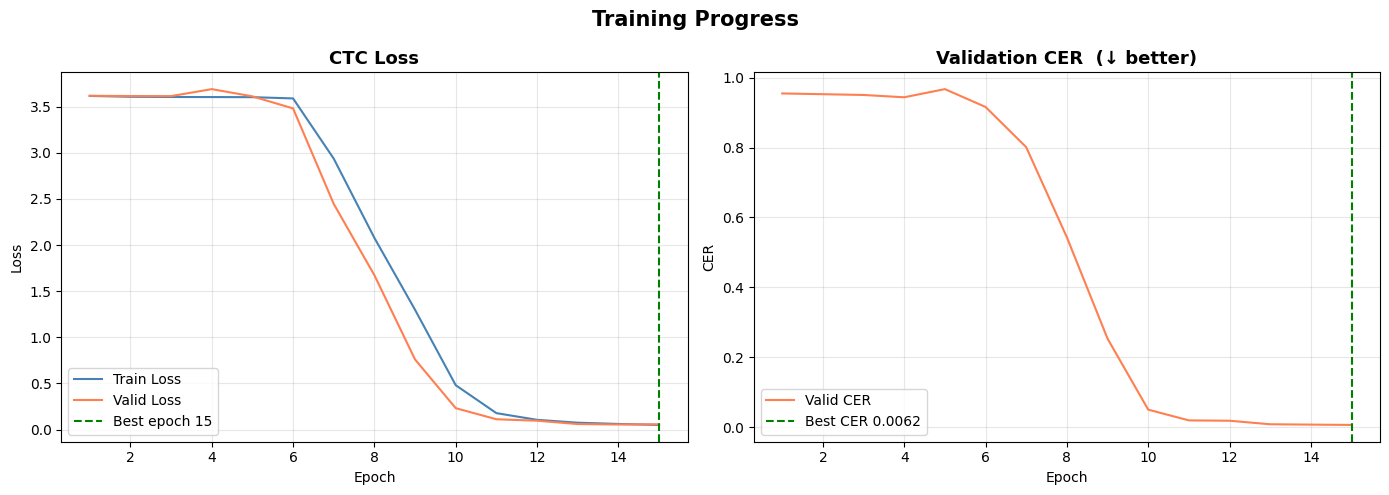

Best epoch : 15
Best CER   : 0.0062
Saved → training_curves.png


In [37]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)
best_ep      = valid_cers.index(min(valid_cers)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, train_losses, label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, valid_losses, label='Valid Loss', color='coral')
axes[0].axvline(best_ep, color='green', linestyle='--', label=f'Best epoch {best_ep}')
axes[0].set_title('CTC Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# CER
axes[1].plot(epochs_range, valid_cers, label='Valid CER', color='coral', linewidth=1.5)
axes[1].axvline(best_ep, color='green', linestyle='--', label=f'Best CER {min(valid_cers):.4f}')
axes[1].set_title('Validation CER  (↓ better)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CER')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training Progress', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best epoch : {best_ep}')
print(f'Best CER   : {min(valid_cers):.4f}')
print('Saved → training_curves.png')


### Generate prediction on test images

In [38]:
import os
import re
import pandas as pd
from torch.utils.data import Dataset, DataLoader

print('Test image directory:', TEST_IMG_DIR)
test_files = os.listdir(TEST_IMG_DIR)
print('Total test images   :', len(test_files))
print('Sample filenames    :', sorted(test_files, key=lambda x: int(re.search(r'(\d+)', x).group(1)))[:10])


Test image directory: /kaggle/input/datasets/aklduiawrh/cig-dataset/cig_ps/test_images
Total test images   : 5000
Sample filenames    : ['test-0.png', 'test-1.png', 'test-2.png', 'test-3.png', 'test-4.png', 'test-5.png', 'test-6.png', 'test-7.png', 'test-8.png', 'test-9.png']


In [39]:
def extract_number(filename):
    """
    Example:
        test-123.png  ->  123
    """
    match = re.search(r'(\d+)', filename)
    return int(match.group(1)) if match else -1


test_images = os.listdir(TEST_IMG_DIR)
test_images = sorted(test_images, key=extract_number)

test_df = pd.DataFrame({'image': test_images})

print(test_df.head(20))
print('Total test images:', len(test_df))


          image
0    test-0.png
1    test-1.png
2    test-2.png
3    test-3.png
4    test-4.png
5    test-5.png
6    test-6.png
7    test-7.png
8    test-8.png
9    test-9.png
10  test-10.png
11  test-11.png
12  test-12.png
13  test-13.png
14  test-14.png
15  test-15.png
16  test-16.png
17  test-17.png
18  test-18.png
19  test-19.png
Total test images: 5000


In [40]:
class OCRTestDataset(Dataset):
    def __init__(
        self,
        df,
        image_dir,
        img_height=100,
        img_width=200,
        use_clahe=True
    ):
        self.df         = df.reset_index(drop=True)
        self.image_dir  = image_dir
        self.img_height = img_height
        self.img_width  = img_width
        self.use_clahe  = use_clahe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.loc[idx, 'image']
        image_path = os.path.join(self.image_dir, image_name)

        image = preprocess_image(
            image_path=image_path,
            img_height=self.img_height,
            img_width=self.img_width,
            use_clahe=self.use_clahe,
            transform=None       # no augmentation at test time
        )

        return {
            'image'     : image,
            'image_name': image_name
        }


In [41]:
test_dataset = OCRTestDataset(
    df=test_df,
    image_dir=TEST_IMG_DIR,
    img_height=100,
    img_width=200,
    use_clahe=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print('Test dataset size :', len(test_dataset))
print('Test batches      :', len(test_loader))


Test dataset size : 5000
Test batches      : 79


In [42]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

print('Best model loaded successfully')


Best model loaded successfully


In [43]:
test_predictions = []
test_image_names = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        images      = batch['image'].to(device)
        image_names = batch['image_name']

        logits = model(images)

        pred_texts = greedy_decode(logits)

        test_predictions.extend(pred_texts)
        test_image_names.extend(image_names)

print('Total predictions  :', len(test_predictions))
print('Total image names  :', len(test_image_names))

print('\nSample predictions (first 20):')
for i in range(20):
    print(f'  {test_image_names[i]}  ->  {test_predictions[i]}')


Total predictions  : 5000
Total image names  : 5000

Sample predictions (first 20):
  test-0.png  ->  QVTQ8A
  test-1.png  ->  7PSW9D
  test-2.png  ->  WJ2WNY
  test-3.png  ->  RFHJD4
  test-4.png  ->  K7ZUF2
  test-5.png  ->  CPMUBK
  test-6.png  ->  UZDRAW
  test-7.png  ->  2YDPJR
  test-8.png  ->  H5SG63
  test-9.png  ->  B2Z823
  test-10.png  ->  7DUP98
  test-11.png  ->  6CUKRD
  test-12.png  ->  DX3YJ3
  test-13.png  ->  YWU8AG
  test-14.png  ->  WYKX9E
  test-15.png  ->  QKEDQ2
  test-16.png  ->  UFCQ5W
  test-17.png  ->  SBPNTN
  test-18.png  ->  BPTGHT
  test-19.png  ->  MA6CZN


In [44]:
submission = pd.DataFrame({
    'image'     : test_image_names,
    'prediction': test_predictions
})

submission.head(20)


,image,prediction
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-2.png,WJ2WNY
3,test-3.png,RFHJD4
4,test-4.png,K7ZUF2
5,test-5.png,CPMUBK
6,test-6.png,UZDRAW
7,test-7.png,2YDPJR
8,test-8.png,H5SG63
9,test-9.png,B2Z823
